library

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


Load Dataset


In [82]:

file_path = "disease_prediction.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst 10 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (4998, 16)

First 10 Rows:


,fever,cough,headache,nausea,vomiting,fatigue,sore_throat,chills,body_pain,loss_of_appetite,abdominal_pain,diarrhea,sweating,rapid_breathing,dizziness,label
0,1,1,1,1,0,0,0,1,1,1,1,0,0,0,0,Typhoid
1,1,0,1,0,1,0,1,1,0,0,1,0,1,1,0,Malaria
2,1,1,1,1,1,1,0,0,0,1,1,1,1,0,1,Typhoid
3,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0,Malaria
4,1,1,1,1,1,0,0,1,1,0,1,1,1,0,1,Typhoid



Column Names:
['fever', 'cough', 'headache', 'nausea', 'vomiting', 'fatigue', 'sore_throat', 'chills', 'body_pain', 'loss_of_appetite', 'abdominal_pain', 'diarrhea', 'sweating', 'rapid_breathing', 'dizziness', 'label']


Check Dataset 


In [83]:

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDisease Distribution:")
print(df['label'].value_counts())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   fever             4998 non-null   int64 
 1   cough             4998 non-null   int64 
 2   headache          4998 non-null   int64 
 3   nausea            4998 non-null   int64 
 4   vomiting          4998 non-null   int64 
 5   fatigue           4998 non-null   int64 
 6   sore_throat       4998 non-null   int64 
 7   chills            4998 non-null   int64 
 8   body_pain         4998 non-null   int64 
 9   loss_of_appetite  4998 non-null   int64 
 10  abdominal_pain    4998 non-null   int64 
 11  diarrhea          4998 non-null   int64 
 12  sweating          4998 non-null   int64 
 13  rapid_breathing   4998 non-null   int64 
 14  dizziness         4998 non-null   int64 
 15  label             4998 non-null   object
dtypes: int64(15), object(1)
memory usage: 

Features and Target

In [84]:
X = df.drop('label', axis=1)
y = df['label']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)




Feature Shape: (4998, 15)
Target Shape: (4998,)


Train-Test Split


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)




Training Data: (3998, 15)
Testing Data: (1000, 15)


Feature Scaling


In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


SVM Model

In [87]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

 Train SVM Model


In [88]:
svm_model.fit(X_train_scaled, y_train)

print("\nSVM Model Training Completed!")



SVM Model Training Completed!


Prediction  Test Data


In [89]:
y_pred = svm_model.predict(X_test_scaled)



Calculate Evaluation Metrics


In [90]:

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

Display Evaluation Metrics


In [91]:
print(" SVM MODEL PERFORMANCE")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")



 SVM MODEL PERFORMANCE
Accuracy  : 0.8770
Precision : 0.8769
Recall    : 0.8770
F1 Score  : 0.8769


Classification Report


In [100]:
print("CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Malaria       0.84      0.83      0.84       333
   Pneumonia       0.90      0.90      0.90       333
     Typhoid       0.88      0.89      0.89       334

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



Confusion Matrix


In [93]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=svm_model.classes_
)

print("  CONFUSION MATRIX")

print(cm)


  CONFUSION MATRIX
[[278  27  28]
 [ 20 301  12]
 [ 31   5 298]]


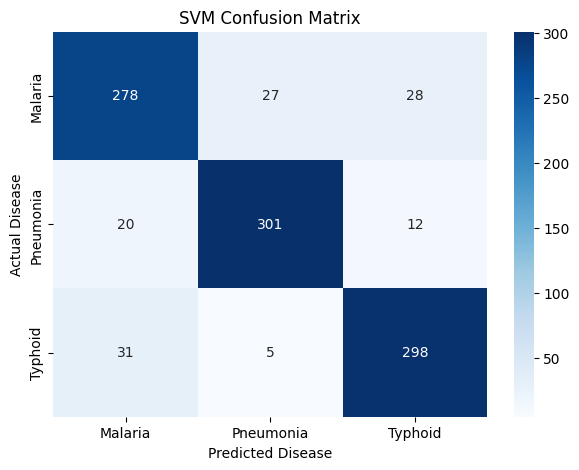

In [94]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("SVM Confusion Matrix")

plt.show()

 New Patient Disease Prediction


In [95]:
# Symptoms:
# 1 = Present
# 0 = Absent

new_patient = {
    'fever': 1,
    'cough': 1,
    'headache': 1,
    'nausea': 0,
    'vomiting': 0,
    'fatigue': 1,
    'sore_throat': 0,
    'chills': 1,
    'body_pain': 1,
    'loss_of_appetite': 1,
    'abdominal_pain': 0,
    'diarrhea': 0,
    'sweating': 1,
    'rapid_breathing': 0,
    'dizziness': 0
}



Convert New Patient to DataFrame


In [98]:
new_patient_df = pd.DataFrame(
    [new_patient],
    columns=X.columns
)

print("\nNew Patient Symptoms:")
display(new_patient_df)

new_patient_scaled = scaler.transform(new_patient_df)

predicted_disease = svm_model.predict(
    new_patient_scaled
)




New Patient Symptoms:


,fever,cough,headache,nausea,vomiting,fatigue,sore_throat,chills,body_pain,loss_of_appetite,abdominal_pain,diarrhea,sweating,rapid_breathing,dizziness
0,1,1,1,0,0,1,0,1,1,1,0,0,1,0,0


Prediction


In [99]:
print("NEW PATIENT PREDICTION")

print("Predicted Disease:", predicted_disease[0])

NEW PATIENT PREDICTION
Predicted Disease: Malaria
